In [1]:
pwd

'/Users/siqianli/Desktop'

In [3]:
cd EIS_knee_point/

/Users/siqianli/Desktop/EIS_knee_point


In [96]:
from sklearn.metrics import make_scorer, r2_score
r2_scorer = make_scorer(r2_score)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
R^2: 0.9446771005245826
RMSE: 5.703091674690354
MAE: 4.095001444930122
83.52243
83


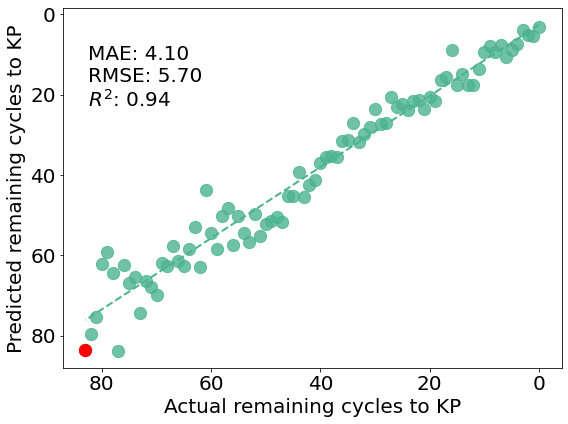

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 设置参数网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# 创建和运行GridSearchCV
model = XGBRegressor(objective='reg:squarederror', seed=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # 使用负平均绝对误差
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

# 获取最佳参数和最佳模型
best_params = grid_search.best_params_
best_xgb = grid_search.best_estimator_
print("Best Parameters:", best_params)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 使用最佳模型进行预测
Y_test_rul = best_xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},
    line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'},
    ci=None,
    color='#4cb391',
)

# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')
print(Y_test_rul[0])
print(rultest[0])
# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}",
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
plt.show()

# all features for KP

[63.174522 71.90023  64.248276 42.356197 69.349236 73.58335  69.57464
 61.922817 68.98136  64.90297  61.67078  65.775505 67.20004  61.857864
 66.8511   66.183365 59.306305 61.846268 60.675808 60.745808 63.98248
 67.13733  65.78251  58.287365 59.541958 55.864517 58.033188 61.37232
 54.212784 57.600735 52.644524 48.747856 47.286816 52.121548 49.12645
 55.24945  49.770054 49.5211   46.14697  52.316467 44.460526 46.85394
 43.013474 44.58893  36.787918 36.97531  43.274788 33.038807 30.018797
 36.029114 23.292904 33.370144 40.35316  27.13617  25.133223 36.163128
 31.318903 25.529736 35.018696 21.0474   29.453348 25.900448]
[61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38
 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14
 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
R^2: -0.44341480783316833
RMSE: 21.50008353957194
MAE: 20.579021300038985
61


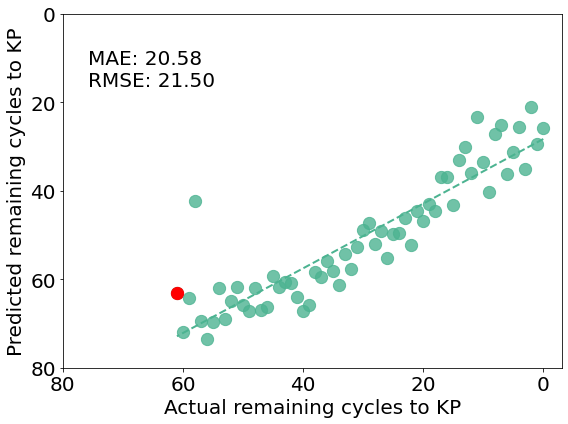

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis504.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_504.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


In [122]:
y_true = np.array([90, 84, 57, 46, 96, 73, 62])
#y_pred_5 = np.array([80, 80, 68, 71, 82, 78, 69])
#y_pred_5 = np.array([62, 72, 62, 67, 70, 71, 64])
y_pred_5 = np.array([75, 81, 60, 66, 87, 82, 63])
#y_pred_all = np.array([73, 81, 58, 70, 82, 78, 64])
#75,81, 64,72, 84, 81, 62
#71, 83, 70
#y_pred_ = np.array([65, 80, 57, 68, 83, 79, 71])
#y_pred_5 = np.array([75,81, 64,72, 84, 81, 62])
#72, 77, 59, 70, 84, 76, 66
#y_pred_5 = np.array([73, 77, 62, 74, 77, 77, 64])
labels = ["Battery 16", "Battery 14", "Battery 12", "Battery 10", "Battery 8", "Battery 6", "Battery 4"]

# 计算 R^2, RMSE, MAE
r2 = r2_score(y_true, y_pred_5)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_5))
mae = mean_absolute_error(y_true, y_pred_5)
mae_percentage = (mae / np.mean(y_true)) * 100  # 转换为百分数
print(r2)
print(mae)
print(mae_percentage)

0.6056200195722075
8.571428571428571
11.811023622047244


In [140]:
y_true = np.array([90, 84, 57, 46, 96, 73, 62])
#y_pred_5 = np.array([80, 80, 68, 71, 82, 78, 69])
#y_pred_5 = np.array([62, 72, 62, 67, 70, 71, 64])
y_pred_5 = np.array([76, 81, 59, 66, 84, 79, 64])
#y_pred_all = np.array([73, 81, 58, 70, 82, 78, 64])
#75,81, 64,72, 84, 81, 62
#71, 83, 70
#y_pred_ = np.array([65, 80, 57, 68, 83, 79, 71])
#y_pred_5 = np.array([75,81, 64,72, 84, 81, 62])
#72, 77, 59, 70, 84, 76, 66
#y_pred_5 = np.array([73, 77, 62, 74, 77, 77, 64])
labels = ["Battery 16", "Battery 14", "Battery 12", "Battery 10", "Battery 8", "Battery 6", "Battery 4"]

# 计算 R^2, RMSE, MAE
r2 = r2_score(y_true, y_pred_5)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_5))
mae = mean_absolute_error(y_true, y_pred_5)
mae_percentage = (mae / np.mean(y_true)) * 100  # 转换为百分数
print(r2)
print(mae)
print(mae_percentage)

0.6119809869984623
8.428571428571429
11.614173228346457


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
R^2: 0.9047147558890328
RMSE: 7.484636470814027
MAE: 6.143151737394787
73.211426
83


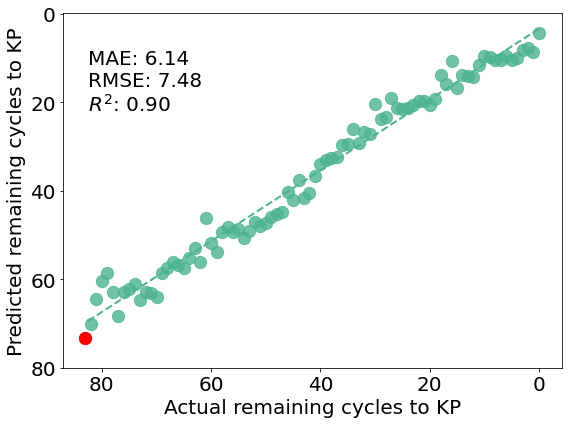

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 设置参数网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# 创建和运行GridSearchCV
model = XGBRegressor(objective='reg:squarederror', seed=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

# 获取最佳参数和最佳模型
best_params = grid_search.best_params_
best_xgb = grid_search.best_estimator_
print("Best Parameters:", best_params)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 使用最佳模型进行预测
Y_test_rul = best_xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},
    line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'},
    ci=None,
    color='#4cb391',
)

# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')
print(Y_test_rul[0])
print(rultest[0])
# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}",
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 设置参数网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

# 创建和运行GridSearchCV
model = XGBRegressor(objective='reg:squarederror', seed=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

# 获取最佳参数和最佳模型
best_params = grid_search.best_params_
best_xgb = grid_search.best_estimator_
print("Best Parameters:", best_params)



Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}


In [ ]:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}

In [ ]:
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}

[73.677704  76.10228   70.927185  70.77873   62.572292  67.08287
 78.421326  67.07776   67.50605   63.53417   74.588974  65.62857
 66.29907   72.54894   64.167175  62.16791   58.246983  59.054504
 61.21825   57.40191   53.184998  59.839024  48.526375  56.74504
 58.600124  53.201744  48.976013  52.232628  52.36518   56.21277
 51.31141   47.71103   50.15538   48.8118    48.711647  48.262753
 47.65511   43.37421   45.671158  38.804005  43.555862  39.893986
 41.175194  36.350853  36.275803  35.24296   34.10887   32.107033
 31.69837   29.296616  32.50913   31.015234  28.635603  20.956266
 25.88151   25.711441  20.635775  23.625647  24.128496  23.305056
 23.921503  21.794968  23.643528  20.740051  22.076254  13.571806
 14.855771  13.515389  18.622969  12.557056  14.320084  15.015314
 10.75692    9.118481   9.85315   10.914904  10.763565  10.186687
 11.480429   9.213789   5.4836345  6.7460175  8.799725   3.7721543]
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 5

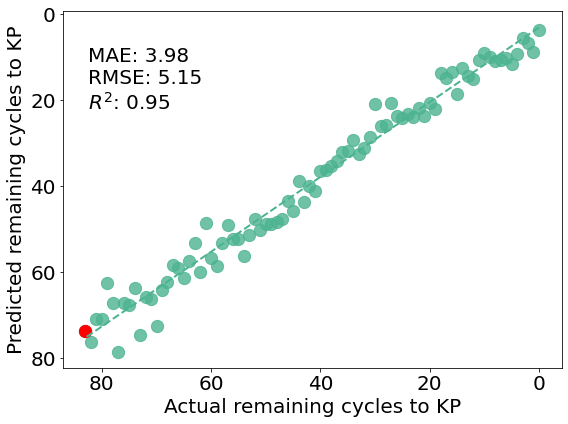

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.8 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


Cross-validation RMSE: 14.62222313010929
R^2: 0.9484008184656618
RMSE: 5.50781434058886
MAE: 4.101106144133068


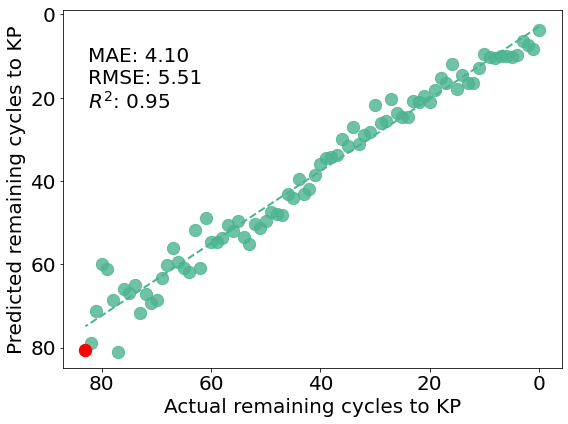

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import cross_val_score

# 数据加载（与之前的代码相同）
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化（与之前的代码相同）
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练（使用手动找到的参数）
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, colsample_bytree=1, subsample=1)
xgb.fit(X_train, Y_train)

# 交叉验证
scores = cross_val_score(xgb, X_train, Y_train, cv=5, scoring='neg_mean_squared_error')  # 使用 5 折交叉验证和负均方误差
rmse_scores = np.sqrt(-scores)  # 将负均方误差转换为 RMSE
print(f'Cross-validation RMSE: {rmse_scores.mean()}')

# 测试集准备（与之前的代码相同）
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL（与之前的代码相同）
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致（与之前的代码相同）
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]

# 计算R^2分数（与之前的代码相同）
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE（与之前的代码相同）
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE（与之前的代码相同）
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图（与之前的代码相同）
plt.figure(figsize=(8, 6))
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},
    line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'},
    ci=None,
    color='#4cb391',
)
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}",
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)
plt.tight_layout()
plt.show()


[71.48347  78.50994  64.859184 83.883286 70.11334  83.71978  84.89763
 81.75455  77.469124 74.21112  71.012985 73.24471  76.5809   81.63856
 76.447914 71.267426 67.2683   69.89221  74.03973  70.83165  71.95922
 72.3756   74.85218  61.155952 70.960976 49.427563 69.90876  57.87332
 67.23702  66.39048  64.52458  56.46116  61.96646  50.936195 60.837887
 56.72448  58.39059  50.736263 47.23126  56.030037 52.726788 56.080063
 41.893528 49.589016 47.597633 45.39402  43.803226 39.369244 47.024788
 27.036055 46.621223 47.070915 44.047333 45.138584 43.133602 27.910423
 37.12393  42.368187 41.401028 38.443874 30.792591 29.866787 29.275648
 25.811794 24.660042 29.92767  29.094887 19.513758 18.444023 21.433779
 21.519817 22.637121 22.61984  20.191368 21.11681  22.995901 18.055115
 19.067802 17.89427  17.752201 16.219238 18.062233 21.178442 15.299177
 15.420577 15.687203 13.936879 13.56601  14.173062 12.867908]
[89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66
 65 64 63 62 61 6

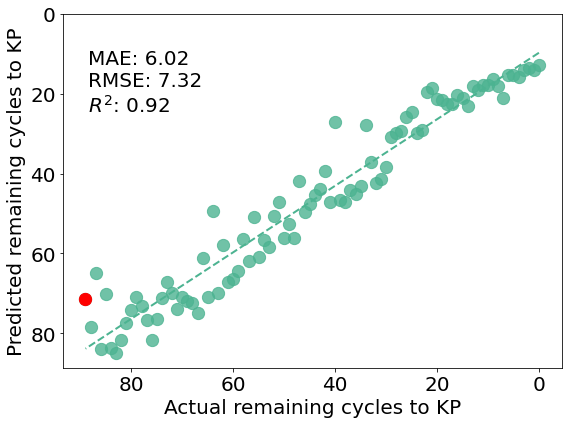

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis516.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_516.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


In [ ]:
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}

In [ ]:
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}

[78.69264  69.75819  69.64281  79.25722  64.81933  67.02931  64.48193
 69.15246  72.74349  68.60757  68.851494 66.76295  62.51756  64.222115
 67.344536 61.975193 62.61662  57.520443 66.57944  59.472095 52.199417
 61.77202  63.796436 61.745922 62.166    62.819553 51.988247 55.942142
 57.58112  53.770058 55.493797 48.785034 56.168243 45.799473 27.153452
 41.503887 47.823227 47.634888 45.60725  29.581207 36.40111  44.98473
 22.268549 43.77008  44.198177 42.171627 43.30233  39.226357 36.713936
 41.268265 38.00997  38.257256 32.78489  38.240425 38.377815 40.49239
 36.401028 35.390434 37.39313  31.325176 35.627438 30.311838 35.5239
 33.80058  29.932436 33.55915  25.569397 29.89205  26.638273 26.552057
 30.394205 19.44022  13.236884]
[72 71 70 69 68 67 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49
 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25
 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1
  0]
R^2: 0.5124271182977108
RMSE: 14.713339

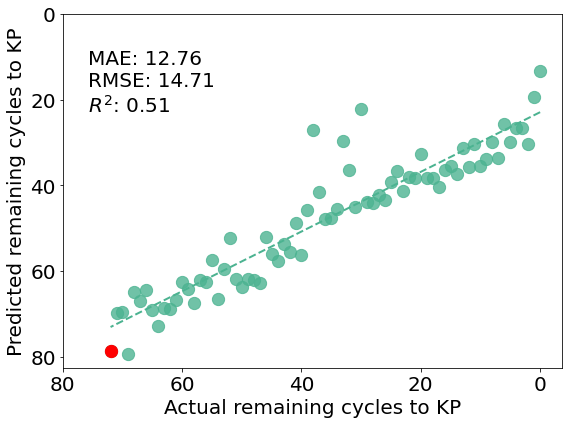

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis506.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_506.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[79.70551   78.58626   69.99506   66.60894   63.704582  66.84532
 80.74282   64.78255   66.52159   64.79299   72.12397   68.2138
 66.23702   67.949684  64.6305    61.71608   57.630737  60.35835
 58.887707  59.86581   54.667282  59.988766  47.01165   56.548233
 60.023827  50.89214   50.296967  51.902016  50.77344   53.220135
 50.677937  47.04705   48.40397   50.669315  49.870087  47.28226
 45.379993  42.70577   44.03717   38.619865  44.145344  41.650337
 41.084606  36.767326  36.00634   34.64538   34.352016  30.68038
 32.17029   29.047102  33.816044  28.73914   28.67927   21.925913
 25.067417  25.068998  22.025806  21.487     23.199545  23.535135
 21.435469  21.956095  22.431517  21.995401  18.805655  15.339894
 16.190996  10.911919  18.851631  13.997622  13.761251  14.503439
 12.289674  10.909616   8.740471  10.690138   8.352776   9.885531
  8.171511   8.248429   5.0890613  5.357132   8.035254   1.6553017]
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 58 

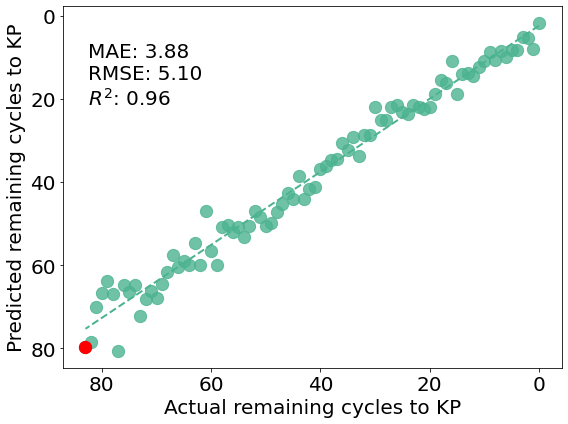

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


In [2]:
pwd

'/Users/siqianli/Desktop'

[79.70551 78.58626 69.99506]
[83 82 81]
R^2: -70.80795032362221
RMSE: 6.918957066091306
MAE: 5.904388427734375
83


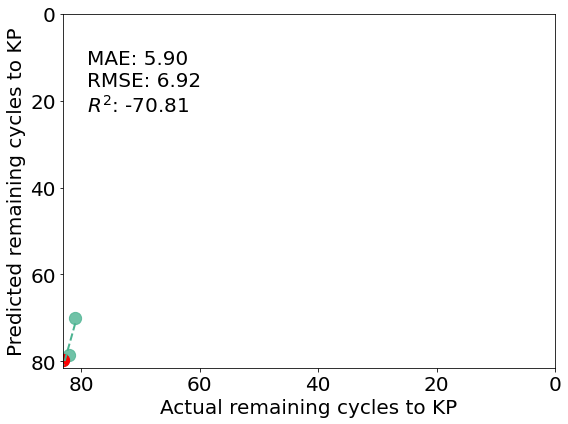

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None, nrows=3).values # 只读取第一行
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',

)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}",
            fontsize=20, transform=plt.gca().transAxes,
            verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()

In [4]:
cd EIS_knee_point/

/Users/siqianli/Desktop/EIS_knee_point


[79.70551 78.58626 69.99506 66.60894]
[83 82 81 80]
R^2: -63.587277047231325
RMSE: 8.985215429194737
MAE: 7.776056289672852
83


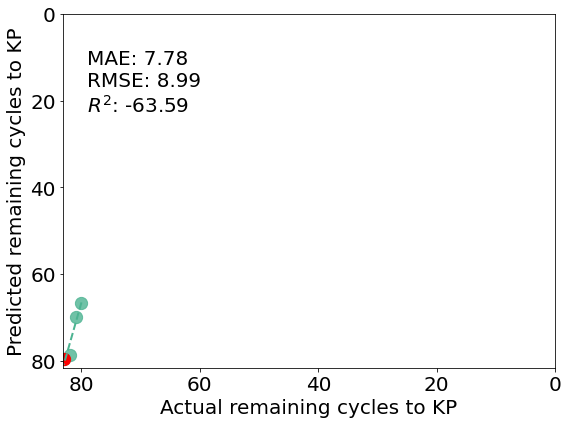

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None, nrows=4).values # 只读取第一行
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',

)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}",
            fontsize=20, transform=plt.gca().transAxes,
            verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()

[68.63373   70.747826  68.88428   63.273895  62.679855  67.40624
 66.88733   64.68365   64.65329   61.391777  60.576412  63.998466
 54.273586  65.300644  60.145264  54.026867  56.716022  53.21837
 49.627388  45.016636  40.4361    41.186214  39.655766  39.647335
 38.49764   36.030277  33.092594  31.60525   29.059982  26.640274
 16.816938  25.706696  26.820576  22.02708   23.363503  24.952677
 14.579699  23.875946  24.040253   9.675107  17.515377  17.675695
 11.431936  11.149023   5.6668468  4.213204   5.5764656  7.1954336
  5.943414  10.0442095  8.660223   7.091122   3.368367   5.289982
  4.9505763  1.8105844  2.5612664]
[56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33
 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9
  8  7  6  5  4  3  2  1  0]
R^2: 0.6669331181178124
RMSE: 9.494740791412482
MAE: 7.428553943048444
56


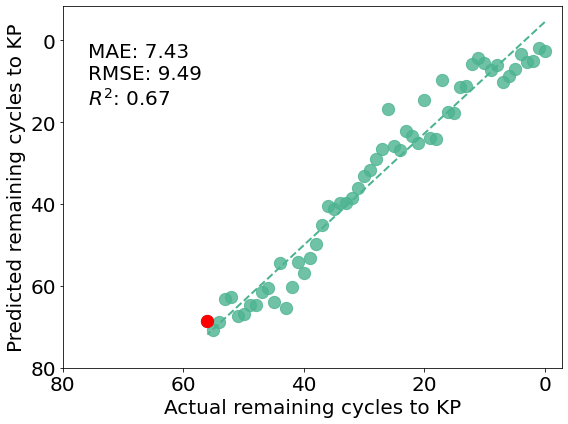

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis512.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_512.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[71.766975  66.66832   74.13415   78.075935  39.433716  41.47168
 41.024788  42.129543  39.81042   39.80871   40.87295   39.27367
 35.774033  35.38125   34.599457  33.82126   33.51503   37.03461
 30.96688   34.204273  26.861433  27.050585  29.05675   26.827776
 25.108925  22.298431  19.823545  19.150745  19.070358  18.45999
 17.351059  15.282778  15.165775  13.492782  12.883267  10.352096
 12.227091   9.876402   8.243983   9.321915   6.2230477  8.451211
  7.6836696  3.296225   3.3363519  4.790491 ]
[45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22
 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
R^2: 0.4982131741430017
RMSE: 9.404250531397807
MAE: 5.425802106442659
45


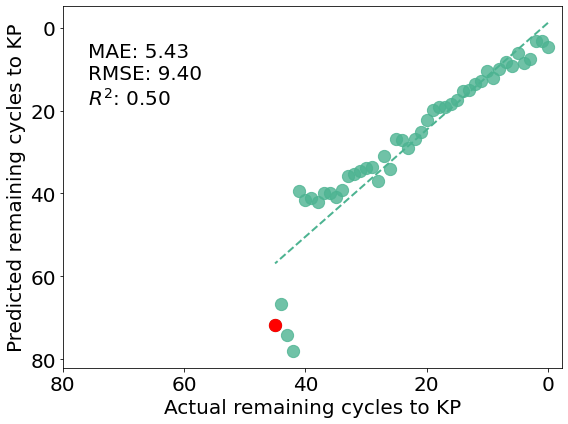

In [56]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis510.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_510.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[82.35674  74.62733  64.92105  70.46707  69.17964  65.33533  74.05179
 75.95783  65.81373  74.99287  67.45672  78.07701  73.36123  67.251175
 81.163925 64.30983  65.170876 63.99482  68.54334  62.460316 63.604565
 43.12912  60.121975 63.712433 61.947937 49.294605 39.49793  69.3677
 59.148876 39.020283 52.98748  38.56534  44.928635 32.00331  33.767338
 37.834156 60.51793  66.58038  66.01513  60.06382  39.329395 57.698177
 62.009617 55.213875 33.788097 31.731918 31.87562  34.90966  35.171375
 33.068825 54.007717 46.069466 40.09917  35.369022 42.090454 38.50396
 29.425411 37.031456 45.485413 44.49181  48.7724   21.493301 44.381275
 47.205173 45.374413 24.478907 46.24693  46.148365 43.155945 18.369267
 24.660812 13.760955 12.784883 15.00461  12.607172 12.870562 14.283834
 13.990647 14.572528 18.200188 13.810938 21.07672  18.528406 16.11525
 24.29286  22.128633 25.348785 24.107176 23.07779  21.694292 23.414515
 20.764881 22.340744 21.502275 19.96949  21.697535]
[95 94 93 92 91 90 89 88 87 86

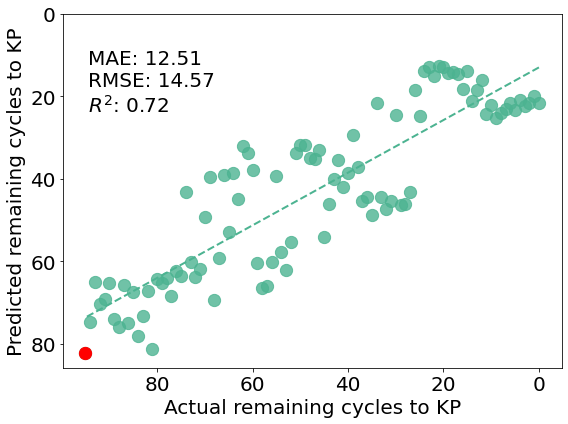

In [57]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis508.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_508.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[69.78437  67.55618  51.924885 44.17829  72.35842  70.15943  73.07598
 65.7237   67.1562   64.11925  64.82436  66.8463   69.79358  66.032425
 64.77247  68.54332  61.041714 64.62118  61.52534  60.875248 65.17429
 65.07808  61.399014 56.22603  60.934296 59.106697 58.82958  59.796715
 51.38287  56.854958 53.465504 49.13337  48.155754 48.470562 50.578552
 55.121025 49.756596 48.814148 45.054855 52.324677 43.71253  46.462242
 42.636074 45.210735 37.65046  38.726715 42.618927 32.966362 26.99721
 39.081116 23.471085 37.70403  36.845448 29.089678 26.068449 35.538387
 31.643332 23.208166 33.252    22.51054  29.801271 23.70016 ]
[61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38
 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14
 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
R^2: -0.4502432342238374
RMSE: 21.550879234040174
MAE: 20.810625353167133
61


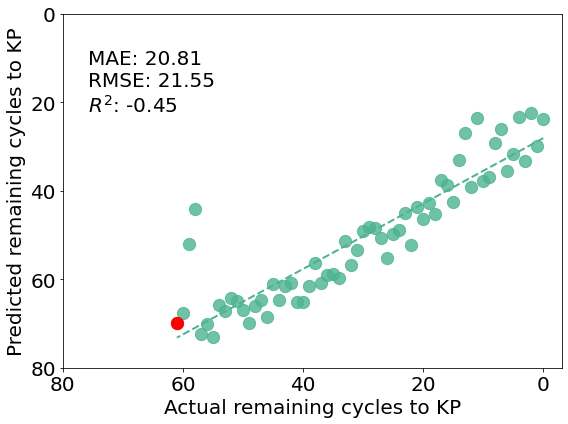

In [58]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis504.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_504.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[79.70551   78.58626   69.99506   66.60894   63.704582  66.84532
 80.74282   64.78255   66.52159   64.79299   72.12397   68.2138
 66.23702   67.949684  64.6305    61.71608   57.630737  60.35835
 58.887707  59.86581   54.667282  59.988766  47.01165   56.548233
 60.023827  50.89214   50.296967  51.902016  50.77344   53.220135
 50.677937  47.04705   48.40397   50.669315  49.870087  47.28226
 45.379993  42.70577   44.03717   38.619865  44.145344  41.650337
 41.084606  36.767326  36.00634   34.64538   34.352016  30.68038
 32.17029   29.047102  33.816044  28.73914   28.67927   21.925913
 25.067417  25.068998  22.025806  21.487     23.199545  23.535135
 21.435469  21.956095  22.431517  21.995401  18.805655  15.339894
 16.190996  10.911919  18.851631  13.997622  13.761251  14.503439
 12.289674  10.909616   8.740471  10.690138   8.352776   9.885531
  8.171511   8.248429   5.0890613  5.357132   8.035254   1.6553017]
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 58 

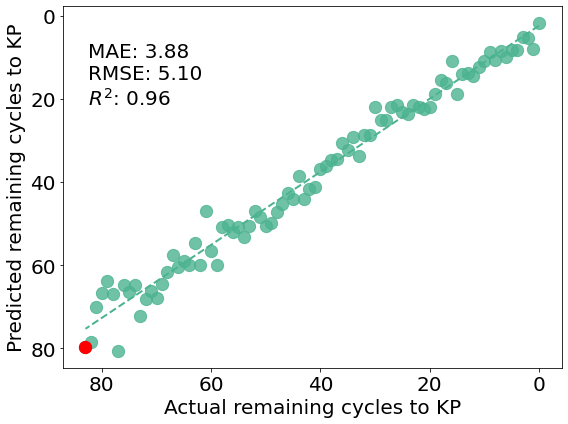

In [62]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,colsample_bytree = 0.8, subsample = 0.8)
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
#xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5,colsample_bytree = 0.6, subsample = 0.6 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[62.302658 67.44711  63.643448 66.068115 62.977055 71.46274  70.048706
 72.67298  69.433174 69.15241  69.65559  67.59229  69.45944  70.663345
 65.08866  62.880024 53.875965 62.678577 65.43744  58.058495 63.990795
 68.89633  62.09469  57.364746 61.709366 48.701885 66.878044 55.75137
 60.944065 60.770626 46.645004 45.90167  60.3802   45.224598 58.74025
 52.52302  54.90315  40.652317 40.81197  52.522835 40.414684 54.14256
 40.997223 44.111683 42.919147 46.589756 42.80203  37.203506 43.978153
 25.298426 42.3991   43.08525  38.530735 42.297977 40.991924 21.845488
 33.335445 39.60613  37.750244 36.753235 20.584902 27.402002 28.085073
 19.519398 22.259333 28.809551 23.469429 23.040327 22.378284 24.695396
 23.621592 21.311783 21.48493  20.376852 20.56978  19.948751 17.846287
 19.709707 17.841555 15.705078 16.334429 17.360521 19.295458 14.996193
 15.356161 15.81665  13.52919  13.402003 12.740673 12.392205]
[89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66
 65 64 63 62 61 

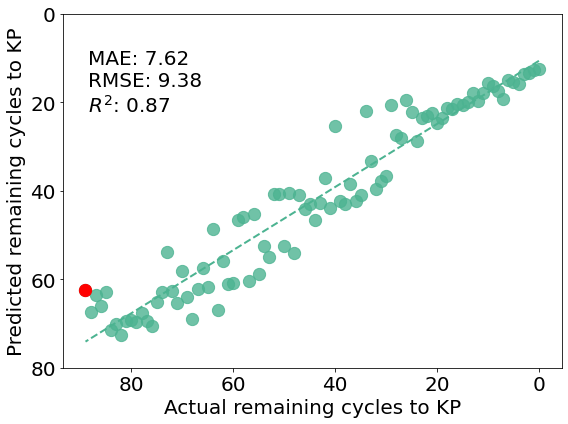

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis516.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_516.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[72.36233   67.592735  65.25455   63.02395   57.89034   61.272465
 68.18375   63.96977   62.07462   60.506695  64.75427   62.298725
 62.798615  62.677387  58.196518  57.587906  56.995697  57.490467
 57.492325  55.25164   52.582508  55.647884  44.507507  51.97876
 54.063225  49.769764  48.218616  49.307335  49.058037  50.341576
 49.14335   47.45943   48.217094  47.394855  46.998837  46.38954
 45.326538  41.514267  41.551323  39.142048  41.715782  40.514786
 36.882816  34.200905  33.12196   32.450745  31.962048  29.60665
 29.356716  26.224846  28.992369  27.413742  26.741705  20.668234
 23.596397  23.364405  18.796448  21.868055  21.113852  21.130043
 19.923582  19.614986  19.239086  19.50171   18.782337  14.277299
 16.407888  11.653267  17.041054  13.721973  14.669847  15.024459
 11.028668   9.731332   9.813426  10.519415   9.827909   9.653288
 10.317763   9.728147   7.59441    7.550273   8.55331    4.2944627]
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 

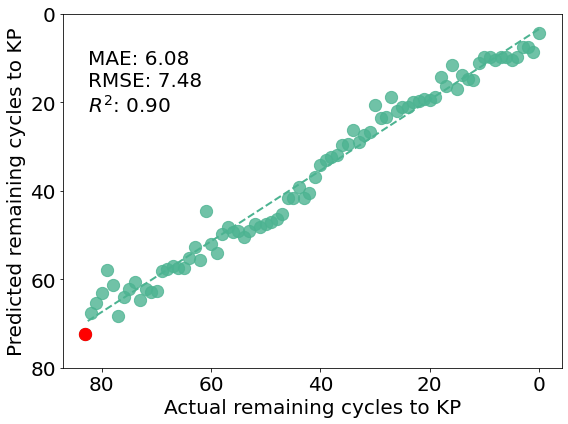

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[61.594795  66.436264  64.51699   60.069687  59.103577  63.69017
 65.379395  62.753384  63.406216  60.08043   62.345383  60.231953
 52.638466  59.484158  54.917717  50.06434   54.237408  52.881306
 44.737267  42.171608  38.553253  37.97196   38.26841   33.038647
 34.350883  32.05741   28.7237    28.876839  26.49771   24.342167
 15.704814  21.454996  22.081972  19.596914  20.418432  20.67376
 17.667845  20.384283  19.89326   10.915711  15.914528  17.910282
 12.794539  12.506161   7.5043964  4.834029   5.2567325  9.228654
  4.6255608  9.641153  11.052722   7.233163   3.8810062  5.3364263
  3.9831543  2.8056428  2.8130085]
[56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33
 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9
  8  7  6  5  4  3  2  1  0]
R^2: 0.7843930934002612
RMSE: 7.639214797324566
MAE: 5.701596628155625
56


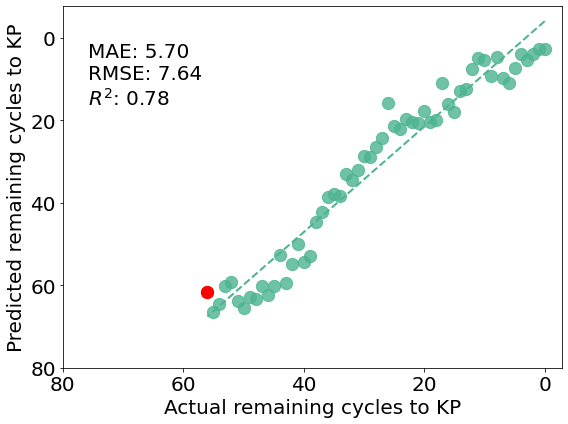

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis512.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_512.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[66.795715  62.137222  67.956566  66.268486  39.496674  42.00221
 41.351135  40.13614   39.20108   39.528275  38.874622  39.30991
 38.56474   38.4055    35.77581   35.403053  36.119705  35.883537
 34.712708  36.58151   29.396942  31.182302  28.967752  27.109756
 25.117502  22.72938   20.361082  19.537632  19.099094  18.960247
 16.638906  16.351347  15.722268  13.133516  13.319139  10.636848
 12.4903    10.801221   7.555464   8.765084   6.1929936  8.156455
  6.0561666  4.4061832  4.3271427  4.6932383]
[45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22
 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
R^2: 0.6555053569375442
RMSE: 7.792122999527013
MAE: 5.309113264083862
45


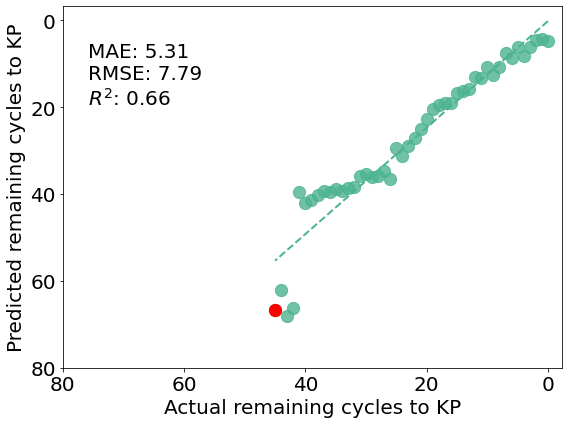

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis510.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_510.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[70.43831  68.25265  57.406147 63.30363  61.8134   61.21729  70.31357
 70.70446  66.532486 70.08084  63.358368 69.419365 66.64911  63.211063
 70.16467  62.308014 63.313385 61.689495 61.538345 59.140987 61.838654
 39.711502 58.10594  58.940628 56.802006 46.380444 36.573055 63.231236
 51.63767  33.47267  53.45216  39.00798  46.46877  33.063007 34.23411
 37.216747 59.090332 62.680466 61.70707  57.49664  42.342228 55.143726
 59.536514 56.129753 33.70991  32.54189  33.288937 34.394753 36.587162
 33.50901  49.510746 41.49546  37.913548 36.155556 39.32908  37.892143
 25.115587 40.14689  44.912704 43.85273  45.17101  19.291126 42.416794
 44.589615 42.685272 18.92971  40.13074  42.566    37.928696 16.166275
 26.180786 14.060385 12.842048 13.124155 12.985504 12.952372 12.497902
 13.249048 13.242142 14.057734 13.138032 19.957584 15.90914  14.26343
 23.121597 15.827647 17.166517 17.140158 22.173079 17.47139  19.713448
 18.628286 17.403576 17.003078 16.868439 17.600027]
[95 94 93 92 91 90 89 88 87 

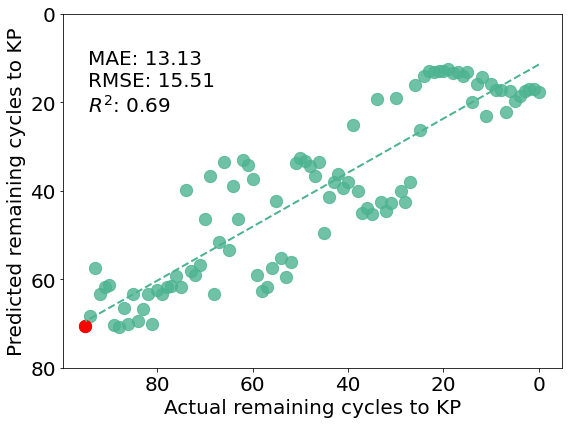

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis508.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_508.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[64.34745  64.624306 53.33403  45.533535 60.559494 63.95511  64.85341
 63.92289  64.94816  63.251633 62.77162  64.10307  63.259083 59.898277
 61.59973  60.74615  57.414692 59.7285   58.854057 59.129124 61.620663
 59.270473 59.153633 48.99897  53.23149  54.465954 55.85842  57.07124
 47.615868 55.68674  50.52081  49.59772  45.8899   47.07876  46.12789
 52.417274 47.27534  42.26188  42.64222  51.094322 38.560867 43.79051
 38.429745 42.61603  34.73017  35.589725 42.60569  31.636677 31.081606
 39.358776 22.70534  34.514984 36.866627 26.69798  23.540915 33.400288
 30.293856 26.13938  34.40685  19.802258 30.159527 25.132664]
[61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38
 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14
 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
R^2: -0.13513992581376644
RMSE: 19.06642497275928
MAE: 17.93611655696746
61


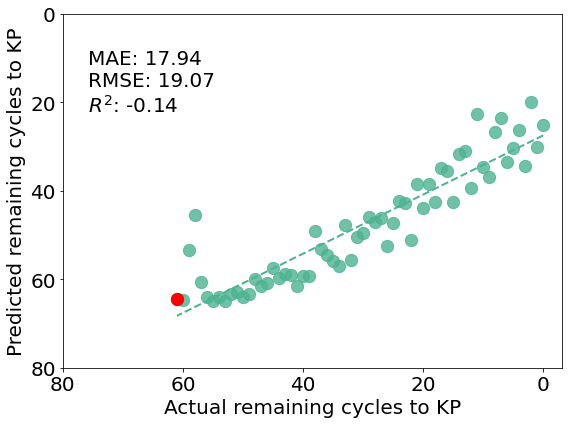

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis504.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_504.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[71.19033  67.60338  62.16885  68.887505 57.699432 63.25583  63.098133
 68.44863  68.47882  65.34483  63.37449  64.29037  57.93224  60.402298
 62.53917  57.439    59.48115  57.16626  62.069332 56.836246 48.910427
 57.882618 60.23185  54.30178  57.468388 59.58101  48.403343 54.41779
 55.584263 51.27864  49.85619  44.75828  49.405514 43.733788 29.83526
 42.049763 45.829098 45.82068  39.627422 31.55724  36.082497 39.50014
 30.039478 39.292164 40.84243  38.19907  43.02049  40.954735 32.354027
 38.919987 33.103672 33.12689  35.697117 35.915092 37.866608 37.93646
 35.438526 35.837    33.564217 27.602137 34.70253  30.590244 33.73044
 32.220737 25.068928 33.00141  24.44269  29.925701 24.06959  25.660315
 29.579922 19.83956  12.409963]
[72 71 70 69 68 67 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49
 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25
 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1
  0]
R^2: 0.6251413103268806
RMSE: 12.901056

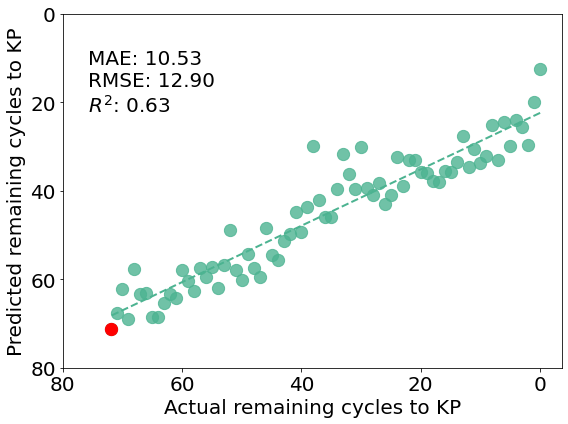

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis506.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_506.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5,colsample_bytree = 0.7, subsample = 0.7 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


In [72]:
import shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
#xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.8, subsample = 0.6 )
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1 )
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 预测测试集的RUL
Y_test_rul = xgb.predict(X_test_rul)

# 确保rultest和Y_test_rul长度一致
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]
print(Y_test_rul)
print(rultest)
# 计算预测值的标准差
std_dev = np.std(Y_test_rul)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()


[22:18:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-10.9-x86_64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "xgb" } are not used.

Top 5 Features Index: [ 0  1 37  2 68]
R^2 with top 5 features: 0.8959404436730206
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36
 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12
 11 10  9  8  7  6  5  4  3  2  1  0]
[78.71664   77.38059   70.74374   77.01686   56.495464  73.49902
 74.60478   69.708595  73.63665   48.02933   60.64682   65.07893
 66.53734   70.33793   65.41854   58.743248  59.251106  44.28113
 56.69361   62.894264  55.148144  50.131718  40.951622  47.64164
 52.077335  50.652878  49.606773  47.99806   48.427734  47.934467
 37.720177  43.36073   46.1202    45.422215  48.981113  46.666943
 43.884407  40.789894  43.815502  37.9551    45.19746   41.918495
 40.479427  39.59302   34

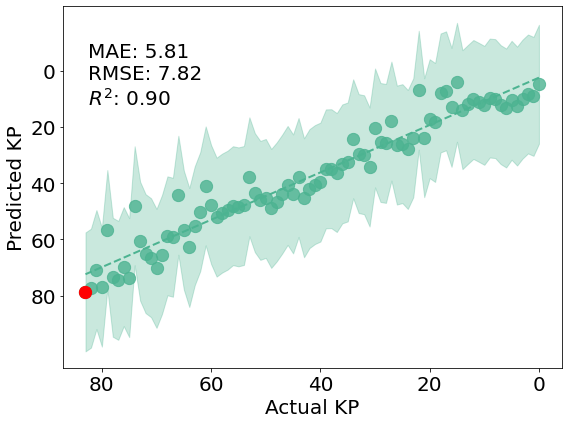

In [129]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# Model training
xgb = XGBRegressor(xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1 ) )
xgb.fit(X_train, Y_train)

# Testing set preparation
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# Use SHAP to explain model predictions
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# Get the mean absolute SHAP values for each feature
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# Get indices of top 5 features based on SHAP values
top_5_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]
print("Top 5 Features Index:", top_5_features_idx)

# Use only the top 5 features for further training
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul_top_5 = X_test_rul[:, top_5_features_idx]

# Train a new model with the top 5 features
xgb_top_5 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1 )
xgb_top_5.fit(X_train_top_5, Y_train)

# RUL prediction for the testing cell with top 5 features
Y_test_rul_top_5 = xgb_top_5.predict(X_test_rul_top_5)

# Ensure both have the same length
min_length = min(len(rultest), len(Y_test_rul_top_5))
rultest = rultest[:min_length]
Y_test_rul_top_5 = Y_test_rul_top_5[:min_length]

# Calculate R^2 score
r2_top_5 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2 with top 5 features: {r2_top_5}')
print(rultest)
print(Y_test_rul_top_5)
# Calculate RMSE
rmse_top_5 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE with top 5 features: {rmse_top_5}')
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_5)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul_top_5,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
)

# 添加 ±1 标准差的阴影区域
plt.fill_between(
    rultest,
    Y_test_rul_top_5 - std_dev,
    Y_test_rul_top_5 + std_dev,
    color='#4cb391',
    alpha=0.3,
    label='±1 Std. Dev'
)

# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul_top_5[0], color='r', s=150, label='First Point')

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

# 设置轴标签
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare516.pdf', bbox_inches='tight')
plt.show()


Top 5 Features Index: [ 1  0  4 37 56]
R^2 with top 5 features: 0.893690998476865
RMSE with top 5 features: 7.905746885155327
MAE: 6.651656082698277


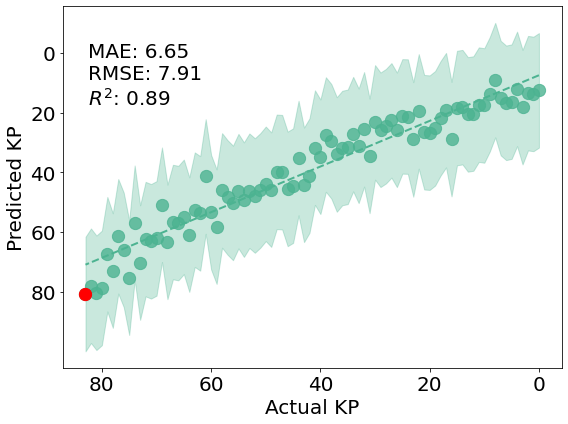

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
import shap

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb.fit(X_train, Y_train)

# 使用 SHAP 解释模型预测
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# 获取每个特征的平均绝对 SHAP 值
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# 获取基于 SHAP 值的前 5 个特征的索引
top_5_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]
print("Top 5 Features Index:", top_5_features_idx)

# 使用前 5 个特征进行进一步训练
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul_top_5 = (EIS_data_test - mean_EIS) / std_EIS
X_test_rul_top_5 = X_test_rul_top_5[:, top_5_features_idx]

# 使用前 5 个特征训练新模型
xgb_top_5 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb_top_5.fit(X_train_top_5, Y_train)

# 使用前 5 个特征预测测试集的 RUL
Y_test_rul_top_5 = xgb_top_5.predict(X_test_rul_top_5)

# 确保长度一致
min_length = min(len(rultest), len(Y_test_rul_top_5))
rultest = rultest[:min_length]
Y_test_rul_top_5 = Y_test_rul_top_5[:min_length]

# 计算评估指标
r2_top_5 = r2_score(rultest, Y_test_rul_top_5)
rmse_top_5 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
mae = mean_absolute_error(rultest, Y_test_rul_top_5)

print(f'R^2 with top 5 features: {r2_top_5}')
print(f'RMSE with top 5 features: {rmse_top_5}')
print(f'MAE: {mae}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_5)

# 绘制回归图
plt.figure(figsize=(8, 6))

sns.regplot(x=rultest, y=Y_test_rul_top_5, scatter_kws={'s': 150},
            line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'}, ci=None, color='#4cb391')

plt.fill_between(rultest, Y_test_rul_top_5 - std_dev, Y_test_rul_top_5 + std_dev,
                 color='#4cb391', alpha=0.3, label='±1 Std. Dev')

plt.scatter(rultest[0], Y_test_rul_top_5[0], color='r', s=150, label='First Point')

ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse_top_5:.2f}\n$R^2$: {r2_top_5:.2f}",
         fontsize=20, transform=plt.gca().transAxes, verticalalignment='top')

plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

plt.tight_layout()
plt.show()

Top 5 Features Index: [ 0  1  4 37 56]
R^2 with top 5 features: 0.7348356957901211
[89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66
 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42
 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18
 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
[60.564377 67.75829  59.561977 56.448235 60.762135 63.615383 63.873005
 63.75158  63.286762 59.246002 65.362625 58.72215  52.777218 52.21571
 54.26611  58.186756 41.6372   57.074074 60.399017 56.971478 57.385815
 59.392574 60.531883 51.115498 56.737583 36.884933 60.027927 55.02411
 54.524845 53.058754 43.95447  43.457386 52.44882  43.631577 50.557106
 48.131996 50.888096 39.91971  40.749187 47.420372 39.273563 46.442806
 39.32181  41.680866 41.8876   43.053726 40.07061  40.325626 39.319256
 38.393826 38.229034 39.440536 36.061275 39.753036 35.952694 34.978245
 38.320587 36.57207  36.604816 36.216324 36.4294   35.388393 35.281185
 35.0

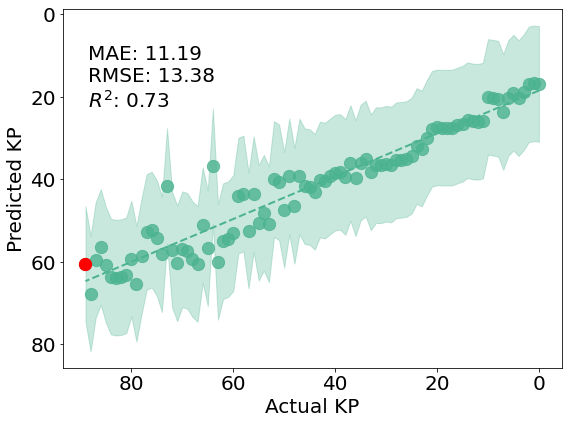

In [106]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis516.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_516.csv', header=None).values.flatten()

mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# Model training
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb.fit(X_train, Y_train)

# Testing set preparation
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# Use SHAP to explain model predictions
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# Get the mean absolute SHAP values for each feature
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# Get indices of top 5 features based on SHAP values
top_5_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]
print("Top 5 Features Index:", top_5_features_idx)

# Use only the top 5 features for further training
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul_top_5 = X_test_rul[:, top_5_features_idx]

# Train a new model with the top 5 features
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5 )
xgb_top_5.fit(X_train_top_5, Y_train)

# RUL prediction for the testing cell with top 5 features
Y_test_rul_top_5 = xgb_top_5.predict(X_test_rul_top_5)

# Ensure both have the same length
min_length = min(len(rultest), len(Y_test_rul_top_5))
rultest = rultest[:min_length]
Y_test_rul_top_5 = Y_test_rul_top_5[:min_length]

# Calculate R^2 score
r2_top_5 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2 with top 5 features: {r2_top_5}')
print(rultest)
print(Y_test_rul_top_5)
# Calculate RMSE
rmse_top_5 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE with top 5 features: {rmse_top_5}')
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_5)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul_top_5,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
)

# 添加 ±1 标准差的阴影区域
plt.fill_between(
    rultest,
    Y_test_rul_top_5 - std_dev,
    Y_test_rul_top_5 + std_dev,
    color='#4cb391',
    alpha=0.3,
    label='±1 Std. Dev'
)

# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul_top_5[0], color='r', s=150, label='First Point')

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

# 设置轴标签
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KPcompare516.pdf', bbox_inches='tight')
plt.show()


In [86]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 初始模型训练
xgb = xgb.XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5, colsample_bytree=0.7, subsample=0.7)
xgb.fit(X_train, Y_train)

# 使用 SHAP 进行特征选择
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)
top_5_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]

# 选择 top 5 特征
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS
X_test_rul_top_5 = X_test_rul[:, top_5_features_idx]

# 使用 top 5 特征进行参数优化
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}


grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', seed=42), # Corrected line
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_top_5, Y_train)

best_params = grid_search.best_params_
best_xgb_top_5 = grid_search.best_estimator_
print("Best Parameters with top 5 features:", best_params)

# 使用最佳模型进行预测
Y_test_rul_top_5_optimized = best_xgb_top_5.predict(X_test_rul_top_5)

# 评估模型性能
min_length = min(len(rultest), len(Y_test_rul_top_5_optimized))
rultest = rultest[:min_length]
Y_test_rul_top_5_optimized = Y_test_rul_top_5_optimized[:min_length]

r2_optimized = r2_score(rultest, Y_test_rul_top_5_optimized)
rmse_optimized = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5_optimized))
mae_optimized = mean_absolute_error(rultest, Y_test_rul_top_5_optimized)

print(f'Optimized R^2 with top 5 features: {r2_optimized}')
print(f'Optimized RMSE with top 5 features: {rmse_optimized}')
print(f'Optimized MAE with top 5 features: {mae_optimized}')

# 绘制回归图
plt.figure(figsize=(8, 6))
sns.regplot(
    x=rultest,
    y=Y_test_rul_top_5_optimized,
    scatter_kws={'s': 150},
    line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'},
    ci=None,
    color='#4cb391',
)

std_dev = np.std(Y_test_rul_top_5_optimized)
plt.fill_between(
    rultest,
    Y_test_rul_top_5_optimized - std_dev,
    Y_test_rul_top_5_optimized + std_dev,
    color='#4cb391',
    alpha=0.3,
    label='±1 Std. Dev'
)

plt.scatter(rultest[0], Y_test_rul_top_5_optimized[0], color='r', s=150, label='First Point')

ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae_optimized:.2f}\nRMSE: {rmse_optimized:.2f}\n$R^2$: {r2_optimized:.2f}",
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

plt.tight_layout()
plt.show()

AttributeError: 'XGBRegressor' object has no attribute 'XGBRegressor'

In [87]:
model_shap = XGBRegressor(objective='reg:squarederror', seed=42)

Fitting 5 folds for each of 675 candidates, totalling 3375 fits
Best Parameters with top 5 features: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.6}
Optimized R^2 with top 5 features: 0.7381823755174755
Optimized RMSE with top 5 features: 12.406729829425275
Optimized MAE with top 5 features: 10.924463953290667


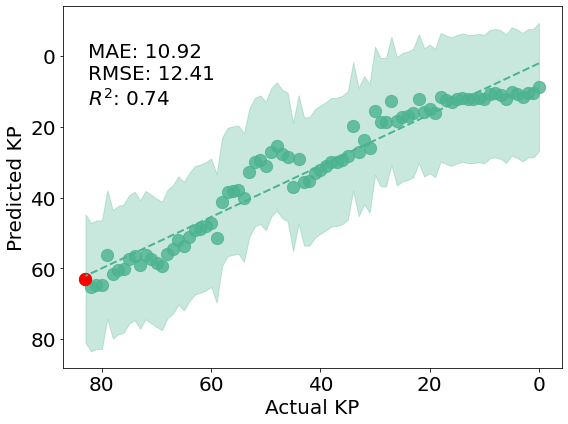

In [90]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 初始模型训练
xgb = xgb.XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=5, colsample_bytree=0.7, subsample=0.7)
xgb.fit(X_train, Y_train)

# 使用 SHAP 进行特征选择
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)
top_5_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]

# 选择 top 5 特征
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS
X_test_rul_top_5 = X_test_rul[:, top_5_features_idx]

# 使用 top 5 特征进行参数优化
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9,1]
}


grid_search = GridSearchCV(
    estimator=model_shap,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_top_5, Y_train)

best_params = grid_search.best_params_
best_xgb_top_5 = grid_search.best_estimator_
print("Best Parameters with top 5 features:", best_params)

# 使用最佳模型进行预测
Y_test_rul_top_5_optimized = best_xgb_top_5.predict(X_test_rul_top_5)

# 评估模型性能
min_length = min(len(rultest), len(Y_test_rul_top_5_optimized))
rultest = rultest[:min_length]
Y_test_rul_top_5_optimized = Y_test_rul_top_5_optimized[:min_length]

r2_optimized = r2_score(rultest, Y_test_rul_top_5_optimized)
rmse_optimized = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5_optimized))
mae_optimized = mean_absolute_error(rultest, Y_test_rul_top_5_optimized)

print(f'Optimized R^2 with top 5 features: {r2_optimized}')
print(f'Optimized RMSE with top 5 features: {rmse_optimized}')
print(f'Optimized MAE with top 5 features: {mae_optimized}')

# 绘制回归图
plt.figure(figsize=(8, 6))
sns.regplot(
    x=rultest,
    y=Y_test_rul_top_5_optimized,
    scatter_kws={'s': 150},
    line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'},
    ci=None,
    color='#4cb391',
)

std_dev = np.std(Y_test_rul_top_5_optimized)
plt.fill_between(
    rultest,
    Y_test_rul_top_5_optimized - std_dev,
    Y_test_rul_top_5_optimized + std_dev,
    color='#4cb391',
    alpha=0.3,
    label='±1 Std. Dev'
)

plt.scatter(rultest[0], Y_test_rul_top_5_optimized[0], color='r', s=150, label='First Point')

ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae_optimized:.2f}\nRMSE: {rmse_optimized:.2f}\n$R^2$: {r2_optimized:.2f}",
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load data
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis506.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_506.csv', header=None).values.flatten()

# Data normalization
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# Train XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, Y_train)

# Testing set preparation
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# RUL prediction for the testing cell
Y_test_rul = model.predict(X_test_rul)

# Ensure both have the same length
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]

# Calculate evaluation metrics
r2 = r2_score(rultest, Y_test_rul)
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul))
mae = mean_absolute_error(rultest, Y_test_rul)

print(f'R^2: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

# Calculate feature importances
feature_importances = model.feature_importances_

# Identify the top 5 features with the highest importance
top_5_indices = np.argsort(feature_importances)[-5:][::-1]  # Get indices of top 5 features
top_5_importances = feature_importances[top_5_indices]      # Get importance values for these features

print("Top 5 Features with Highest Importance:")
for i, (index, importance) in enumerate(zip(top_5_indices, top_5_importances), 1):
    print(f"Rank {i}: Feature {index} with Importance {importance}")

# Create saliency map by tiling the feature importances across test samples
saliency_map = np.tile(feature_importances, (X_test_rul.shape[0], 1)).T

# Plotting the saliency map as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(saliency_map, cmap="viridis", aspect="auto")
plt.colorbar(label="Saliency (Feature Importance)")
plt.xlabel("Test Samples")
plt.ylabel("Features")
plt.title("Saliency Map of Feature Importance for Test Samples")
plt.show()

# Plot the predicted RUL vs. Actual RUL
plt.figure()
plt.plot(rultest, Y_test_rul, 'h', color=[119/255, 172/255, 45/255], linewidth=1, markersize=6, markerfacecolor=[119/255, 172/255, 45/255])
plt.xlabel('Actual RUL', fontsize=20)
plt.ylabel('Predicted RUL', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.savefig("RUL516.pdf", bbox_inches='tight')
plt.show()


# SHAP

Top 5 Features Index: [ 1  0  4 37 56]
R^2 with top 5 features: 0.5893773342617034
[94 93 92 91 90 89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71
 70 69 68 67 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49 48 47
 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23
 22 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
[86.00209   72.815735  73.08362   65.06014   67.10486   62.376686
 51.208897  51.994316  54.86949   47.152744  45.74159   48.68219
 57.787148  49.515835  53.157307  50.46634   55.997593  58.36366
 41.976982  55.881157  57.31863   50.411057  51.818905  58.045216
 54.735798  52.64201   44.833427  51.394623  51.973152  50.949444
 49.83941   40.97368   43.887486  46.825764  42.744465  46.302574
 44.480534  34.456398  38.90643   37.49842   35.555344  28.494455
 38.38296   28.697584  36.65044   30.269308  22.30556   22.307554
 21.761255  41.474808  22.090504  36.079098  39.6855    28.117393
 25.327898  31.456495  25.50216   1

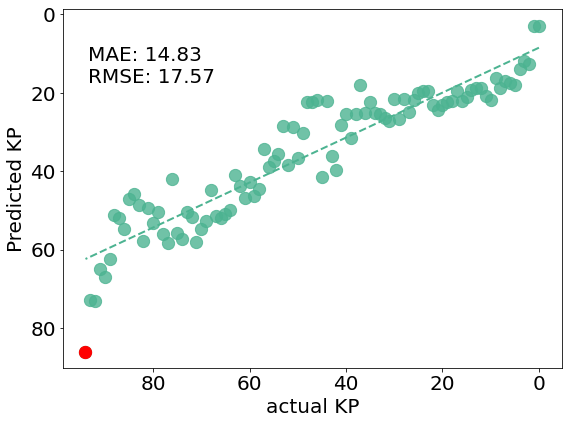

Top 5 Features Index: [ 1  0  4 37 56 66 69 68 71 65]
R^2 with top 5 features: 0.937707796199026
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36
 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12
 11 10  9  8  7  6  5  4  3  2  1  0]
[83.73038   75.743     79.92224   75.22741   61.17484   73.715256
 84.24298   64.09439   65.364746  57.26963   68.52865   67.42528
 63.25217   72.40171   68.11607   55.437763  51.941692  57.40333
 50.680767  61.737892  54.982155  58.245697  40.998142  58.17871
 64.03104   50.81391   48.965706  49.712532  46.602425  53.98542
 46.7844    48.93417   49.91932   51.190388  49.748165  48.014194
 48.600307  42.60503   46.851593  38.72819   46.3797    42.054703
 40.81705   38.525093  34.460907  32.93888   35.565796  32.772385
 32.38091   27.33942   31.676504  30.676004  30.915222  22.446648
 26.78491   26.478432  20.402319  25.13077   24.090742  

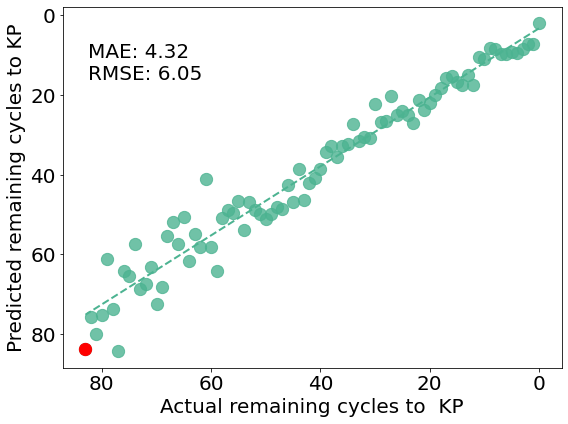

In [222]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# Model training
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1)
xgb.fit(X_train, Y_train)

# Testing set preparation
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# Use SHAP to explain model predictions
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# Get the mean absolute SHAP values for each feature
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# Get indices of top 5 features based on SHAP values
top_5_features_idx = np.argsort(shap_values_abs_mean)[-10:][::-1]
print("Top 5 Features Index:", top_5_features_idx)

# Use only the top 5 features for further training
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul_top_5 = X_test_rul[:, top_5_features_idx]

# Train a new model with the top 5 features
xgb_top_5 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1 )
xgb_top_5.fit(X_train_top_5, Y_train)

# RUL prediction for the testing cell with top 5 features
Y_test_rul_top_5 = xgb_top_5.predict(X_test_rul_top_5)

# Ensure both have the same length
min_length = min(len(rultest), len(Y_test_rul_top_5))
rultest = rultest[:min_length]
Y_test_rul_top_5 = Y_test_rul_top_5[:min_length]

# Calculate R^2 score
r2_top_5 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2 with top 5 features: {r2_top_5}')
print(rultest)
print(Y_test_rul_top_5)
# Calculate RMSE
rmse_top_5 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE with top 5 features: {rmse_top_5}')
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_5)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul_top_5,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul_top_5 - std_dev,
#    Y_test_rul_top_5 + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
#
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul_top_5[0], color='r', s=150, label='First Point')

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

# 设置轴标签
plt.xlabel('Actual remaining cycles to  KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
plt.savefig('KP5140321.pdf', bbox_inches='tight')
plt.show()


# train unseen data

R^2: -0.16616575532783262
RMSE: 15.583774207393443
MAE: 12.35691388130188


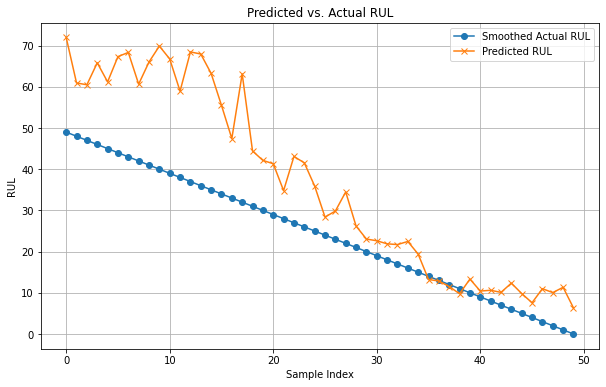

Feature Importances (selected features): {'f0': 493.0, 'f1': 300.0, 'f2': 252.0, 'f3': 567.0, 'f4': 511.0}


In [176]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from statsmodels.nonparametric import smoothers_lowess

# Load data
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis502.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_502.csv', header=None).values.flatten()

# Select only features 0, 1, and 4
selected_features = [1, 0, 4, 37, 56]
EIS_data_RUL = EIS_data_RUL[:, selected_features]
EIS_data_test = EIS_data_test[:, selected_features]

# Normalization (using selected features)
mean_EIS = EIS_data[:, selected_features].mean(axis=0)
std_EIS = EIS_data[:, selected_features].std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# Model training
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb.fit(X_train, Y_train)

# RUL prediction for the testing cell
Y_test_rul = xgb.predict(X_test_rul)

# Ensure both have the same length
min_length = min(len(rultest), len(Y_test_rul))
rultest = rultest[:min_length]
Y_test_rul = Y_test_rul[:min_length]

# Apply LOWESS smoothing to actual RUL
smoothed_rultest = smoothers_lowess.lowess(rultest, np.arange(len(rultest)), frac=0.2)[:, 1]

# Calculate R^2 score
r2 = r2_score(smoothed_rultest, Y_test_rul)
print(f'R^2: {r2}')

# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(smoothed_rultest, Y_test_rul))
mae = mean_absolute_error(smoothed_rultest, Y_test_rul)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

# Plot the predicted RUL vs. actual RUL
plt.figure(figsize=(10, 6))
plt.plot(smoothed_rultest, label="Smoothed Actual RUL", marker='o')
plt.plot(Y_test_rul, label="Predicted RUL", marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("RUL")
plt.title("Predicted vs. Actual RUL")
plt.grid()
plt.show()

# Calculate the feature importances
feature_importances = xgb.get_booster().get_score(importance_type="weight")
print("Feature Importances (selected features):", feature_importances)

Top 5 Features Index: [ 1  0  4 37 56]
R^2 with top 5 features: 0.893690998476865
[83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60
 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36
 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12
 11 10  9  8  7  6  5  4  3  2  1  0]
[80.73961  77.93528  80.29837  78.660995 67.37428  72.85556  61.380108
 65.92895  75.253784 56.845646 70.18273  62.32466  63.06326  62.087498
 50.809483 63.263145 56.608566 56.953537 54.870316 60.823246 52.46393
 53.713158 41.348495 53.349445 58.147182 46.018486 48.366688 50.20776
 46.260887 49.109447 46.11905  47.72687  46.027462 43.81032  45.76182
 39.794777 39.90718  45.509193 44.418736 35.172062 44.152843 41.055565
 31.678257 34.75193  27.296623 29.571411 33.981457 31.816551 31.429234
 27.165358 31.096361 25.559805 34.468105 23.22965  25.715157 24.509983
 22.56597  25.731815 21.229221 21.28785  28.947884 19.54804  26.534906
 26.674364 25.211617 21.8

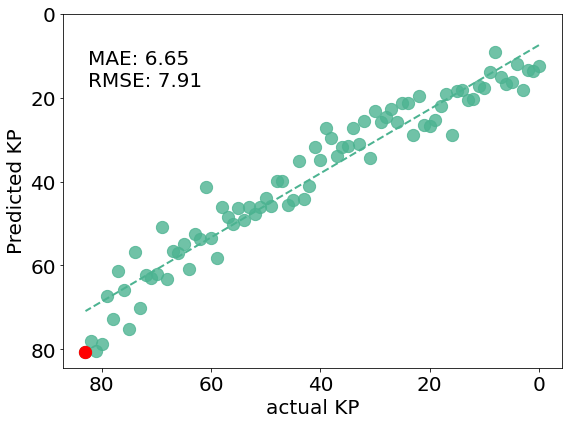

In [221]:
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# Model training
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1)
xgb.fit(X_train, Y_train)

# Testing set preparation
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# Use SHAP to explain model predictions
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# Get the mean absolute SHAP values for each feature
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# Get indices of top 5 features based on SHAP values
top_5_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]
print("Top 5 Features Index:", top_5_features_idx)

# Use only the top 5 features for further training
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul_top_5 = X_test_rul[:, top_5_features_idx]

# Train a new model with the top 5 features
xgb_top_5 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5,colsample_bytree = 0.9, subsample = 1 )
xgb_top_5.fit(X_train_top_5, Y_train)

# RUL prediction for the testing cell with top 5 features
Y_test_rul_top_5 = xgb_top_5.predict(X_test_rul_top_5)

# Ensure both have the same length
min_length = min(len(rultest), len(Y_test_rul_top_5))
rultest = rultest[:min_length]
Y_test_rul_top_5 = Y_test_rul_top_5[:min_length]

# Calculate R^2 score
r2_top_5 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2 with top 5 features: {r2_top_5}')
print(rultest)
print(Y_test_rul_top_5)
# Calculate RMSE
rmse_top_5 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE with top 5 features: {rmse_top_5}')
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_5)

# 计算R^2分数
r2 = r2_score(rultest, Y_test_rul_top_5)
print(f'R^2: {r2}')

# 计算RMSE
rmse = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
print(f'RMSE: {rmse}')

# 计算MAE
mae = mean_absolute_error(rultest, Y_test_rul_top_5)
print(f'MAE: {mae}')

# 绘制回归图
plt.figure(figsize=(8, 6))

# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul_top_5,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul_top_5 - std_dev,
#    Y_test_rul_top_5 + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
#
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul_top_5[0], color='r', s=150, label='First Point')

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')

# 设置轴标签
plt.xlabel('actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

# 显示图形
plt.tight_layout()
#plt.savefig('KP5140320.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# 绘制散点和回归线
sns.regplot(
    x=rultest,
    y=Y_test_rul,
    scatter_kws={'s': 150},  # 调整点的大小
    line_kws={'color': '#4cb391', 'lw': 2,'linestyle': '--'},  # 调整回归线样式
    ci=None,  # 禁用默认置信区间
    color='#4cb391',
    
)

## 添加 ±1 标准差的阴影区域
#plt.fill_between(
#    rultest,
#    Y_test_rul - std_dev,
#    Y_test_rul + std_dev,
#    color='#4cb391',
#    alpha=0.3,
#    label='±1 Std. Dev'
#)
print(rultest[0])
# 自定义第一个点为红色
plt.scatter(rultest[0], Y_test_rul[0], color='r', s=150, label='First Point')

# 添加图例
#plt.legend(fontsize=15)

# 设置x轴和y轴的刻度范围为80, 60, 40, 20, 0，并反转
ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.text(0.05, 0.9, f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\n$R^2$: {r2:.2f}", 
         fontsize=20, transform=plt.gca().transAxes,
         verticalalignment='top')
# 设置轴标签
plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

# 显示图形
plt.tight_layout()
plt.savefig('KPcompare514.pdf', bbox_inches='tight')
plt.show()

Top 5 Features Index: [ 1  4  0 56 66]
R^2 with top 5 features: 0.7576670400953514
RMSE with top 5 features: 12.78884488616202
MAE with top 5 features: 9.74305084016588


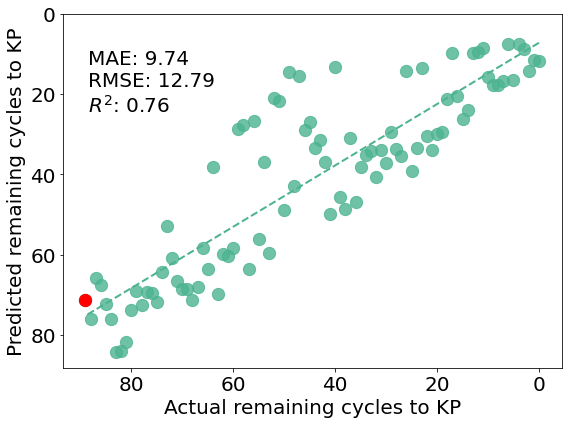

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis516.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_516.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb.fit(X_train, Y_train)

# 获取特征重要性
feature_importance = xgb.feature_importances_

# 选择前 5 个特征
top_5_features_idx = np.argsort(feature_importance)[-5:][::-1]
print("Top 5 Features Index:", top_5_features_idx)

# 使用前 5 个特征重新训练模型
X_train_top_5 = X_train[:, top_5_features_idx]
X_test_rul_top_5 = (EIS_data_test - mean_EIS) / std_EIS
X_test_rul_top_5 = X_test_rul_top_5[:, top_5_features_idx]

xgb_top_5 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb_top_5.fit(X_train_top_5, Y_train)

# 预测测试集的 RUL
Y_test_rul_top_5 = xgb_top_5.predict(X_test_rul_top_5)

# 确保 rultest 和 Y_test_rul_top_5 长度一致
min_length = min(len(rultest), len(Y_test_rul_top_5))
rultest = rultest[:min_length]
Y_test_rul_top_5 = Y_test_rul_top_5[:min_length]

# 计算评估指标
r2_top_5 = r2_score(rultest, Y_test_rul_top_5)
rmse_top_5 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_5))
mae_top_5 = mean_absolute_error(rultest, Y_test_rul_top_5)

print(f'R^2 with top 5 features: {r2_top_5}')
print(f'RMSE with top 5 features: {rmse_top_5}')
print(f'MAE with top 5 features: {mae_top_5}')

# 绘制回归图
plt.figure(figsize=(8, 6))

sns.regplot(x=rultest, y=Y_test_rul_top_5, scatter_kws={'s': 150},
            line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'}, ci=None, color='#4cb391')

plt.scatter(rultest[0], Y_test_rul_top_5[0], color='r', s=150, label='First Point')

ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae_top_5:.2f}\nRMSE: {rmse_top_5:.2f}\n$R^2$: {r2_top_5:.2f}",
         fontsize=20, transform=plt.gca().transAxes, verticalalignment='top')

plt.xlabel('Actual remaining cycles to KP', fontsize=20)
plt.ylabel('Predicted remaining cycles to KP', fontsize=20)

plt.tight_layout()
plt.show()

Top 3 Features Index: [1 0 4]
[77.280396  77.05366   75.195076  73.292816  57.379566  62.740124
 78.19362   67.06205   72.00214   51.55166   48.62508   50.606136
 70.74987   65.68387   48.895622  57.144253  58.455097  58.264965
 55.581398  58.326027  42.78373   54.358112  53.737812  63.701427
 64.45578   55.017952  57.20934   48.98781   47.82615   43.943233
 38.933308  31.376415  28.985977  45.70899   36.748425  44.85365
 38.416023  42.554195  23.465826  32.383575  40.066193   7.660329
 35.758835  35.56018   33.80609   30.678316  31.73935   27.75284
 24.099337  22.549858  27.434355  23.968649  20.946804  19.630167
 22.55301   11.664604  20.282448  24.78967   15.568541  15.292984
  8.694749  11.332555   7.425391   5.4816995 10.735914  12.434418
  6.314491  13.022024  10.728818  13.602696  17.550625  18.645857
 17.31709   12.672354   3.591645  11.247059   6.5862336 15.75566
  7.7850575  5.4748216 15.451253   4.8756995  9.631922   5.7397113
 16.200165   3.751963   4.832085   4.6893516 15.

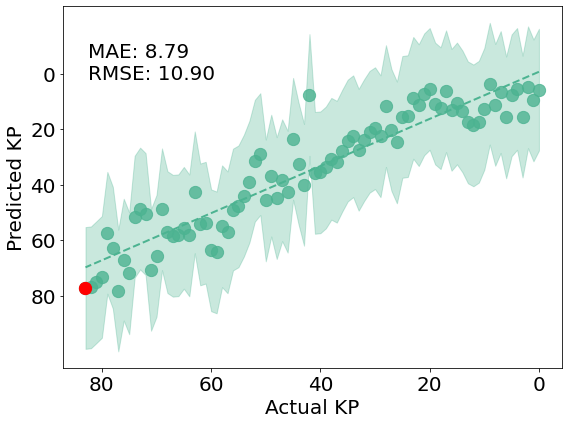

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
import shap

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis514.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_514.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 使用 SHAP 解释模型预测
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# 获取每个特征的平均绝对 SHAP 值
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# 获取基于 SHAP 值的前 3 个特征的索引（修改这里）
top_3_features_idx = np.argsort(shap_values_abs_mean)[-3:][::-1]
print("Top 3 Features Index:", top_3_features_idx)

# 使用前 3 个特征进行进一步训练（修改这里）
X_train_top_3 = X_train[:, top_3_features_idx]
X_test_rul_top_3 = X_test_rul[:, top_3_features_idx]

# 使用前 3 个特征训练新模型（修改这里）
xgb_top_3 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb_top_3.fit(X_train_top_3, Y_train)

# RUL 预测测试集（修改这里）
Y_test_rul_top_3 = xgb_top_3.predict(X_test_rul_top_3)
print(Y_test_rul_top_3)
# 确保长度一致
min_length = min(len(rultest), len(Y_test_rul_top_3))
rultest = rultest[:min_length]
Y_test_rul_top_3 = Y_test_rul_top_3[:min_length]

# 计算评估指标
r2_top_3 = r2_score(rultest, Y_test_rul_top_3)
rmse_top_3 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_3))
mae_top_3 = mean_absolute_error(rultest, Y_test_rul_top_3)

print(f'R^2 with top 3 features: {r2_top_3}')
print(f'RMSE with top 3 features: {rmse_top_3}')
print(f'MAE with top 3 features: {mae_top_3}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_3)

# 绘制回归图
plt.figure(figsize=(8, 6))

sns.regplot(x=rultest, y=Y_test_rul_top_3, scatter_kws={'s': 150},
            line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'}, ci=None, color='#4cb391')

plt.fill_between(rultest, Y_test_rul_top_3 - std_dev, Y_test_rul_top_3 + std_dev,
                 color='#4cb391', alpha=0.3, label='±1 Std. Dev')

plt.scatter(rultest[0], Y_test_rul_top_3[0], color='r', s=150, label='First Point')

ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae_top_3:.2f}\nRMSE: {rmse_top_3:.2f}\n",
         fontsize=20, transform=plt.gca().transAxes, verticalalignment='top')

plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

plt.tight_layout()
plt.show()

8.428571428571429


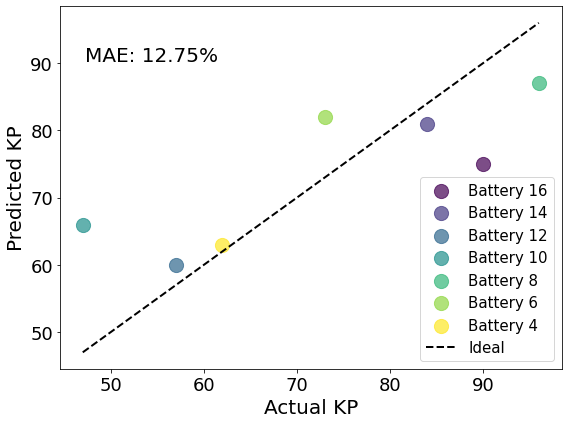

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 实际值和预测值
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred = np.array([75, 81, 60, 66, 87, 82, 63])
labels = ["Battery 16", "Battery 14", "Battery 12", "Battery 10", "Battery 8", "Battery 6", "Battery 4"]

# 计算 R^2, RMSE, MAE
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mae_kp_all = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 创建颜色数组
colors = plt.cm.viridis(np.linspace(0, 1, len(y_true)))  # 使用 Viridis 渐变色

# 创建散点图
plt.figure(figsize=(8, 6))
for i in range(len(y_true)):
    plt.scatter(
        y_true[i],
        y_pred[i],
        color=colors[i],
        s=200,
        alpha=0.7,
        label=labels[i]  # 分配标签
    )

# 添加对角线（理想预测线）
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)
print(mae)
# 设置图例、标题、和轴标签
#plt.title('Actual vs Predicted Values', fontsize=16)
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.legend(fontsize=15)  # 图例放在图外
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
# 显示 R^2, RMSE, 和百分比形式的 MAE 信息
plt.text(
    0.05,
    0.85,
    f"\nMAE: {mae_kp_all:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
)

# 显示图形
#plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("Kneepointall0321.pdf", bbox_inches='tight', dpi=300)
plt.show()


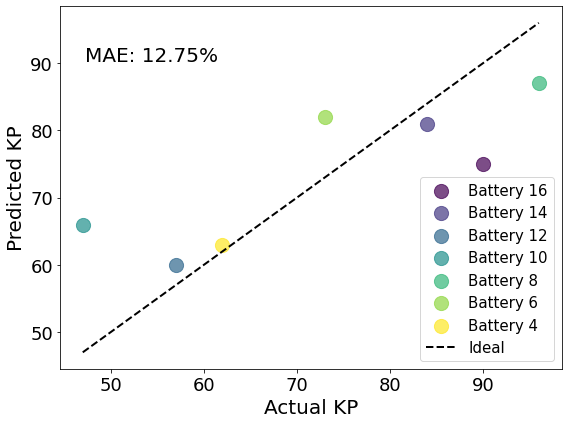

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 实际值和预测值
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred = np.array([75, 81, 60, 66, 87, 82, 63])
labels = ["Battery 16", "Battery 14", "Battery 12", "Battery 10", "Battery 8", "Battery 6", "Battery 4"]

# 计算 R^2, RMSE, MAE
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae_kp_all = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 创建颜色数组
colors = plt.cm.viridis(np.linspace(0, 1, len(y_true)))  # 使用 Viridis 渐变色

# 创建散点图
plt.figure(figsize=(8, 6))
for i in range(len(y_true)):
    plt.scatter(
        y_true[i],
        y_pred[i],
        color=colors[i],
        s=200,
        alpha=0.7,
        label=labels[i]  # 分配标签
    )

# 添加对角线（理想预测线）
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)

# 设置图例、标题、和轴标签
#plt.title('Actual vs Predicted Values', fontsize=16)
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.legend(fontsize=15)  # 图例放在图外
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
# 显示 R^2, RMSE, 和百分比形式的 MAE 信息
plt.text(
    0.05,
    0.85,
    f"\nMAE: {mae_kp_all:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
)

# 显示图形
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Kneepointall0321.pdf", bbox_inches='tight', dpi=300)
plt.show()


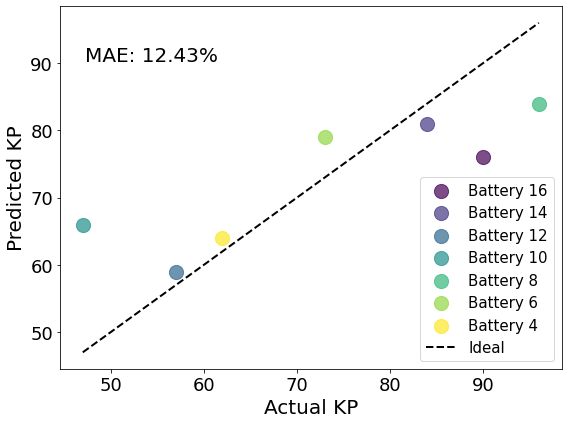

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 实际值和预测值
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred = np.array([76, 81, 59, 66, 84, 79, 64])
labels = ["Battery 16", "Battery 14", "Battery 12", "Battery 10", "Battery 8", "Battery 6", "Battery 4"]

# 计算 R^2, RMSE, MAE
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae_kp_all = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 创建颜色数组
colors = plt.cm.viridis(np.linspace(0, 1, len(y_true)))  # 使用 Viridis 渐变色

# 创建散点图
plt.figure(figsize=(8, 6))
for i in range(len(y_true)):
    plt.scatter(
        y_true[i],
        y_pred[i],
        color=colors[i],
        s=200,
        alpha=0.7,
        label=labels[i]  # 分配标签
    )

# 添加对角线（理想预测线）
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)

# 设置图例、标题、和轴标签
#plt.title('Actual vs Predicted Values', fontsize=16)
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.legend(fontsize=15)  # 图例放在图外
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
# 显示 R^2, RMSE, 和百分比形式的 MAE 信息
plt.text(
    0.05,
    0.85,
    f"\nMAE: {mae_kp_all:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
)

# 显示图形
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("KneepointSHAP5.pdf", bbox_inches='tight', dpi=300)
plt.show()


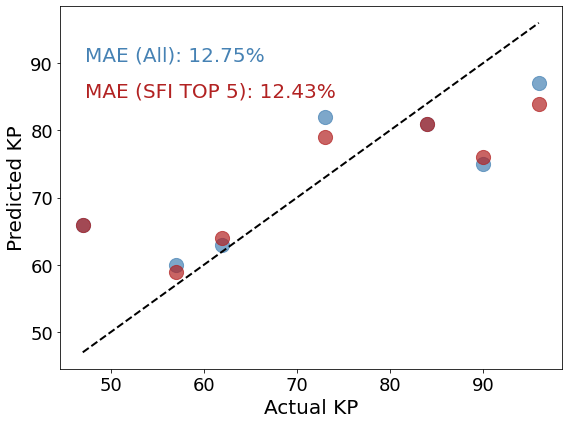

In [190]:
import numpy as np
import matplotlib.pyplot as plt

# Actual values and two prediction sets
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred_all = np.array([75, 81, 60, 66, 87, 82, 63])
y_pred_5 = np.array([76, 81, 59, 66, 84, 79, 64])

# Custom MAE calculation for each prediction
mae_kp_all = np.mean(np.abs((y_true - y_pred_all) / y_true)) * 100  # Percentage form
mae_kp_5 = np.mean(np.abs((y_true - y_pred_5) / y_true)) * 100  # Percentage form

# Create scatter plots
plt.figure(figsize=(8, 6))

# Scatter for y_pred_all in steelblue
plt.scatter(
    y_true,
    y_pred_all,
    color='steelblue',
    s=200,
    alpha=0.7,
    label='Prediction (All)'
)

# Scatter for y_pred_5 in tomato
plt.scatter(
    y_true,
    y_pred_5,
    color='firebrick',
    s=200,
    alpha=0.7,
    label='Prediction (Top 5)'
)

# Add ideal prediction line
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)

# Set labels and title
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Display custom MAE (KP) for both predictions
plt.text(
    0.05,
    0.85,
    f"MAE (All): {mae_kp_all:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
    color='steelblue'
)

plt.text(
    0.05,
    0.75,
    f"MAE (SFI TOP 5): {mae_kp_5:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
    color='firebrick'
)

# Show plot
plt.tight_layout()
plt.savefig("0321KP5.pdf", bbox_inches='tight', dpi=300)
plt.show()


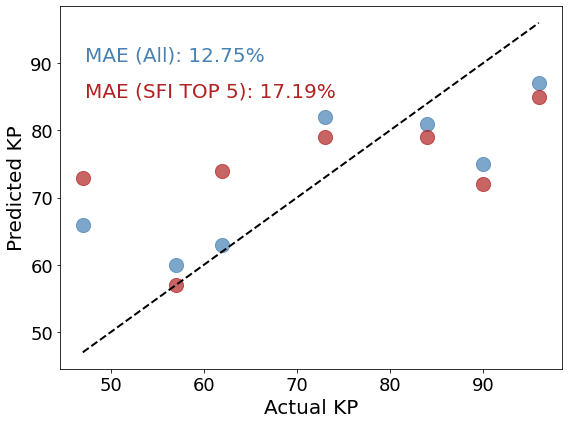

In [216]:
import numpy as np
import matplotlib.pyplot as plt

# Actual values and two prediction sets
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred_all = np.array([75, 81, 60, 66, 87, 82, 63])
y_pred_3 = np.array([72, 79, 57, 73, 85, 79, 74])

# Custom MAE calculation for each prediction
mae_kp_all = np.mean(np.abs((y_true - y_pred_all) / y_true)) * 100  # Percentage form
mae_kp_3 = np.mean(np.abs((y_true - y_pred_3) / y_true)) * 100  # Percentage form

# Create scatter plots
plt.figure(figsize=(8, 6))

# Scatter for y_pred_all in steelblue
plt.scatter(
    y_true,
    y_pred_all,
    color='steelblue',
    s=200,
    alpha=0.7,
    label='Prediction (All)'
)

# Scatter for y_pred_5 in tomato
plt.scatter(
    y_true,
    y_pred_3,
    color='firebrick',
    s=200,
    alpha=0.7,
    label='Prediction (Top 5)'
)

# Add ideal prediction line
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)

# Set labels and title
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Display custom MAE (KP) for both predictions
plt.text(
    0.05,
    0.85,
    f"MAE (All): {mae_kp_all:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
    color='steelblue'
)

plt.text(
    0.05,
    0.75,
    f"MAE (SFI TOP 5): {mae_kp_3:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=20,
    color='firebrick'
)

# Show plot
plt.tight_layout()
#plt.savefig("0321KP5.pdf", bbox_inches='tight', dpi=300)
plt.show()


Top 3 Features Index: [ 1  0  4 37 56]
[49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26
 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2
  1  0]
[79.197266  60.79712   62.513344  63.751957  61.864742  67.50709
 67.84562   57.525505  65.00949   69.54525   66.87602   57.882557
 62.8313    68.52147   63.022335  55.23755   50.775303  60.720875
 47.70719   44.02885   46.925755  40.836327  43.80251   38.09694
 37.71946   29.208582  31.851433  31.536366  28.518394  23.191643
 25.623894  21.757107  25.698996  20.205822  24.402155  12.813145
 10.457368   8.7782755 10.104182  11.706796  11.377104   9.983369
 10.012063  14.045349   8.44413   10.18895   13.251542   9.459327
 11.8078     6.7196307]
R^2 with top 3 features: -0.2085645648319414
RMSE with top 3 features: 15.864538147272105
MAE with top 3 features: 13.047586011886597


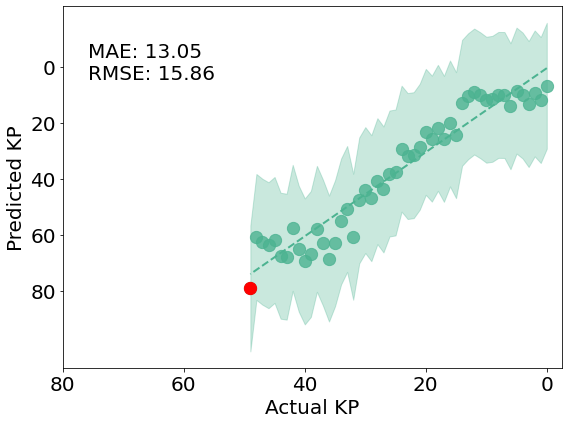

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
import shap

# 数据加载
EIS_data = pd.read_csv('eis_train_cha0.csv', header=None).values
RUL = pd.read_csv('KPtrainnew.csv', header=None).values
EIS_data_RUL = pd.read_csv('eis_kp_cha0.csv', header=None).values
EIS_data_test = pd.read_csv('eis502.csv', header=None).values
rultest = pd.read_csv('kp_eis_kp_cha0_502.csv', header=None).values.flatten()

# 数据标准化
mean_EIS = EIS_data.mean(axis=0)
std_EIS = EIS_data.std(axis=0)
X_train = (EIS_data_RUL - mean_EIS) / std_EIS
Y_train = RUL

# 模型训练
xgb = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb.fit(X_train, Y_train)

# 测试集准备
X_test_rul = (EIS_data_test - mean_EIS) / std_EIS

# 使用 SHAP 解释模型预测
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# 获取每个特征的平均绝对 SHAP 值
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# 获取基于 SHAP 值的前 3 个特征的索引（修改这里）
top_3_features_idx = np.argsort(shap_values_abs_mean)[-5:][::-1]
print("Top 3 Features Index:", top_3_features_idx)

# 使用前 3 个特征进行进一步训练（修改这里）
X_train_top_3 = X_train[:, top_3_features_idx]
X_test_rul_top_3 = X_test_rul[:, top_3_features_idx]

# 使用前 3 个特征训练新模型（修改这里）
xgb_top_3 = XGBRegressor(n_estimators=200, learning_rate=0.2, max_depth=5, colsample_bytree=0.9, subsample=1)
xgb_top_3.fit(X_train_top_3, Y_train)

# RUL 预测测试集（修改这里）
Y_test_rul_top_3 = xgb_top_3.predict(X_test_rul_top_3)

# 确保长度一致
min_length = min(len(rultest), len(Y_test_rul_top_3))
rultest = rultest[:min_length]
Y_test_rul_top_3 = Y_test_rul_top_3[:min_length]
print(rultest)
print(Y_test_rul_top_3)
# 计算评估指标
r2_top_3 = r2_score(rultest, Y_test_rul_top_3)
rmse_top_3 = np.sqrt(mean_squared_error(rultest, Y_test_rul_top_3))
mae_top_3 = mean_absolute_error(rultest, Y_test_rul_top_3)

print(f'R^2 with top 3 features: {r2_top_3}')
print(f'RMSE with top 3 features: {rmse_top_3}')
print(f'MAE with top 3 features: {mae_top_3}')

# 计算预测值的标准差
std_dev = np.std(Y_test_rul_top_3)

# 绘制回归图
plt.figure(figsize=(8, 6))

sns.regplot(x=rultest, y=Y_test_rul_top_3, scatter_kws={'s': 150},
            line_kws={'color': '#4cb391', 'lw': 2, 'linestyle': '--'}, ci=None, color='#4cb391')

plt.fill_between(rultest, Y_test_rul_top_3 - std_dev, Y_test_rul_top_3 + std_dev,
                 color='#4cb391', alpha=0.3, label='±1 Std. Dev')

plt.scatter(rultest[0], Y_test_rul_top_3[0], color='r', s=150, label='First Point')

ticks = [80, 60, 40, 20, 0]
plt.xticks(ticks, fontsize=20)
plt.yticks(ticks, fontsize=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.text(0.05, 0.9, f"MAE: {mae_top_3:.2f}\nRMSE: {rmse_top_3:.2f}\n",
         fontsize=20, transform=plt.gca().transAxes, verticalalignment='top')

plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)

plt.tight_layout()
plt.show()

In [228]:
[84][79], [95][86], [145][81], [50][80]

[84]

In [236]:
y_true = np.array([84, 95])
y_pred = np.array([79, 86])
#labels = ["Battery 16", "Battery 14", "Battery 12", "Battery 10", "Battery 8", "Battery 6", "Battery 4"]

# 计算 R^2, RMSE, MAE
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae_kp_all = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(mae_kp_all)

7.713032581453634


(array([ 40.,  50.,  60.,  70.,  80.,  90., 100.]),
 [Text(0, 40.0, '40'),
  Text(0, 50.0, '50'),
  Text(0, 60.0, '60'),
  Text(0, 70.0, '70'),
  Text(0, 80.0, '80'),
  Text(0, 90.0, '90'),
  Text(0, 100.0, '100')])

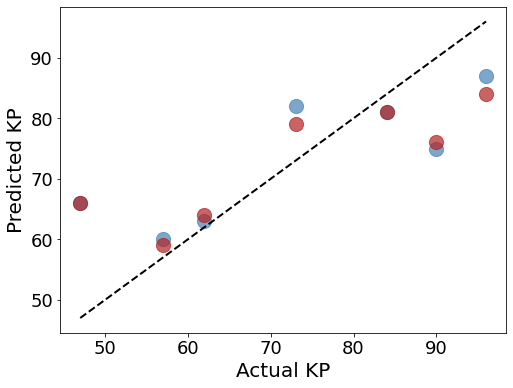

In [237]:
# Actual values and two prediction sets
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred_all = np.array([75, 81, 60, 66, 87, 82, 63])
y_pred_5 = np.array([76, 81, 59, 66, 84, 79, 64])

# Custom MAE calculation for each prediction
mae_kp_all = np.mean(np.abs((y_true - y_pred_all) / y_true)) * 100  # Percentage form
mae_kp_5 = np.mean(np.abs((y_true - y_pred_5) / y_true)) * 100  # Percentage form

# Create scatter plots
plt.figure(figsize=(8, 6))

# Scatter for y_pred_all in steelblue
plt.scatter(
    y_true,
    y_pred_all,
    color='steelblue',
    s=200,
    alpha=0.7,
    label='Prediction (All)'
)

# Scatter for y_pred_5 in tomato
plt.scatter(
    y_true,
    y_pred_5,
    color='firebrick',
    s=200,
    alpha=0.7,
    label='Prediction (Top 5)'
)

# Add ideal prediction line
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)

# Set labels and title
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)


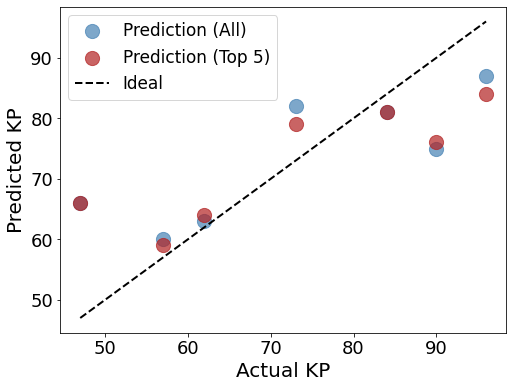

In [241]:
# Actual values and two prediction sets
y_true = np.array([90, 84, 57, 47, 96, 73, 62])
y_pred_all = np.array([75, 81, 60, 66, 87, 82, 63])
y_pred_5 = np.array([76, 81, 59, 66, 84, 79, 64])

# Custom MAE calculation for each prediction
mae_kp_all = np.mean(np.abs((y_true - y_pred_all) / y_true)) * 100  # Percentage form
mae_kp_5 = np.mean(np.abs((y_true - y_pred_5) / y_true)) * 100  # Percentage form

# Create scatter plots
plt.figure(figsize=(8, 6))

# Scatter for y_pred_all in steelblue
plt.scatter(
    y_true,
    y_pred_all,
    color='steelblue',
    s=200,
    alpha=0.7,
    label='Prediction (All)'
)

# Scatter for y_pred_5 in tomato
plt.scatter(
    y_true,
    y_pred_5,
    color='firebrick',
    s=200,
    alpha=0.7,
    label='Prediction (Top 5)'
)

# Add ideal prediction line
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    color='k',
    linestyle='--',
    linewidth=2,
    label='Ideal'
)

# Set labels and title
plt.xlabel('Actual KP', fontsize=20)
plt.ylabel('Predicted KP', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Add legend
plt.legend(fontsize=17)  # 添加图例，并设置字体大小
plt.savefig('as2fc.pdf')
# Show the plot
plt.show()